In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Nassau Candy Distributor.csv to Nassau Candy Distributor.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("Nassau Candy Distributor.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'],
                                 dayfirst= True
                                  )
df['Ship Date'] = pd.to_datetime(df['Ship Date'],
                                dayfirst= True
                                 )

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  object        
 2   Order Date      10194 non-null  datetime64[ns]
 3   Ship Date       10194 non-null  datetime64[ns]
 4   Ship Mode       10194 non-null  object        
 5   Customer ID     10194 non-null  int64         
 6   Country/Region  10194 non-null  object        
 7   City            10194 non-null  object        
 8   State/Province  10194 non-null  object        
 9   Postal Code     10194 non-null  object        
 10  Division        10194 non-null  object        
 11  Region          10194 non-null  object        
 12  Product ID      10194 non-null  object        
 13  Product Name    10194 non-null  object        
 14  Sales           10194 non-null  float64       
 15  Un

In [ ]:
df['Lead_Time'] = (
    df['Ship Date'] - df['Order Date']
).dt.days

print(df['Lead_Time'].describe())

count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Lead_Time, dtype: float64


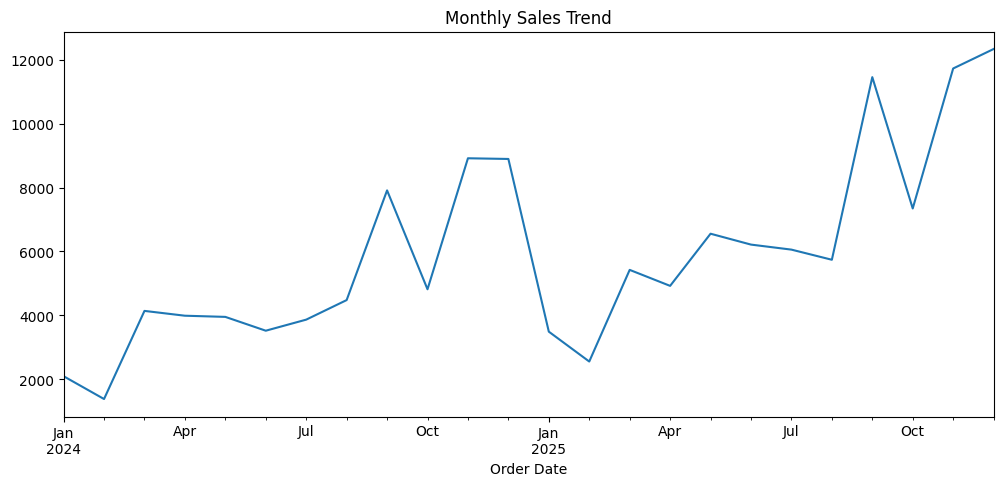

In [ ]:
#Monthly Sales Trend

monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum()

monthly_sales.plot(
    figsize=(12,5)
)

plt.title('Monthly Sales Trend')
plt.show()

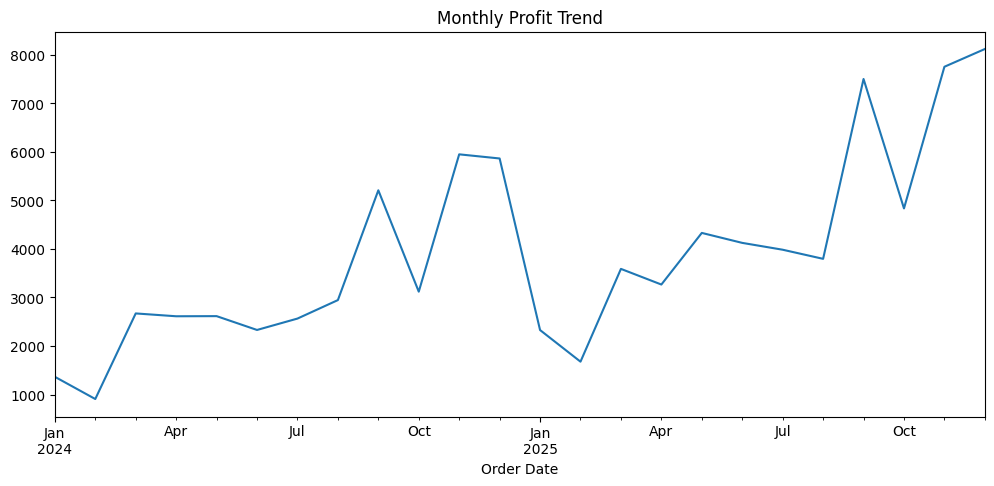

In [ ]:
#Monthly Profit Trend

monthly_profit = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Gross Profit'].sum()

monthly_profit.plot(
    figsize=(12,5)
)

plt.title('Monthly Profit Trend')
plt.show()

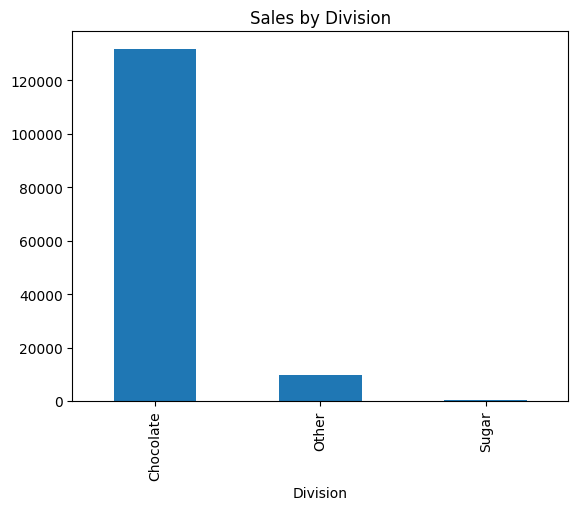

In [ ]:
# Division Performance
division_sales = df.groupby(
    'Division'
)['Sales'].sum()

division_sales.plot(
    kind='bar'
)

plt.title('Sales by Division')
plt.show()

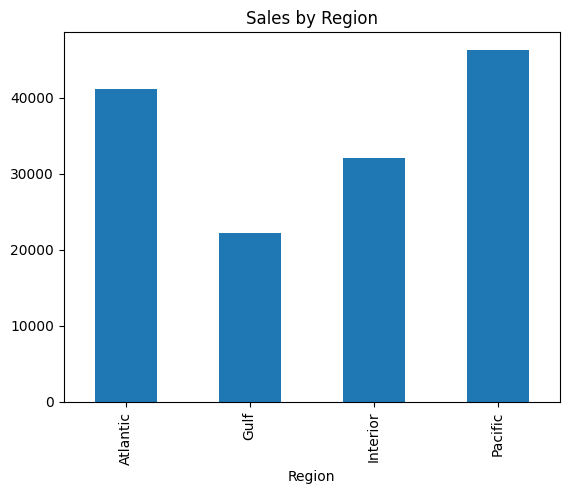

In [ ]:
#Region Performance

region_sales = df.groupby(
    'Region'
)['Sales'].sum()

region_sales.plot(
    kind='bar'
)

plt.title('Sales by Region')
plt.show()

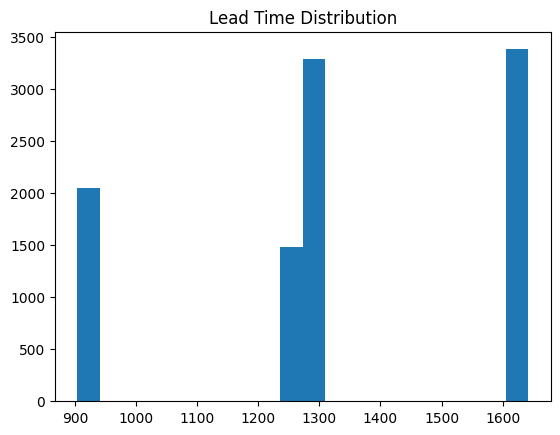

In [ ]:
#Lead Time Distribution
plt.hist(
    df['Lead_Time'],
    bins=20
)

plt.title('Lead Time Distribution')
plt.show()

In [ ]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Country/Region',
 'City',
 'State/Province',
 'Postal Code',
 'Division',
 'Region',
 'Product ID',
 'Product Name',
 'Sales',
 'Units',
 'Gross Profit',
 'Cost',
 'Lead_Time']